In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import skew, kurtosis
from scipy.ndimage import sobel

from skimage.transform import resize
from skimage.metrics import (
    peak_signal_noise_ratio,
    structural_similarity,
    mean_squared_error
)

print("KLA Semiconductor Degradation Analysis Started")

KLA Semiconductor Degradation Analysis Started


In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

print("Random seed fixed:", SEED)

Random seed fixed: 42


In [3]:
GT_PATH = "../data/train/GT"
NOISY_PATH = "../data/train/NoisyLR"

print("GT exists:", os.path.exists(GT_PATH))
print("NoisyLR exists:", os.path.exists(NOISY_PATH))

GT exists: True
NoisyLR exists: True


In [4]:
gt_files = sorted([
    f for f in os.listdir(GT_PATH)
    if f.endswith(".npy")
])

noisy_files = sorted([
    f for f in os.listdir(NOISY_PATH)
    if f.endswith(".npy")
])

common_files = sorted(
    set(gt_files).intersection(noisy_files)
)

print("GT files:", len(gt_files))
print("NoisyLR files:", len(noisy_files))
print("Matched pairs:", len(common_files))

print("\nFirst 5 filenames:")
print(common_files[:5])

GT files: 3200
NoisyLR files: 3200
Matched pairs: 3200

First 5 filenames:
['000000.npy', '000001.npy', '000002.npy', '000003.npy', '000004.npy']


In [5]:
for filename in common_files[:5]:

    gt = np.load(
        os.path.join(GT_PATH, filename)
    )

    noisy = np.load(
        os.path.join(NOISY_PATH, filename)
    )

    print("\nFile:", filename)

    print(
        "GT:",
        gt.shape,
        gt.dtype,
        "min =", gt.min(),
        "max =", gt.max(),
        "mean =", gt.mean(),
        "std =", gt.std()
    )

    print(
        "NoisyLR:",
        noisy.shape,
        noisy.dtype,
        "min =", noisy.min(),
        "max =", noisy.max(),
        "mean =", noisy.mean(),
        "std =", noisy.std()
    )


File: 000000.npy
GT: (256, 256) float32 min = 0.0 max = 1.0 mean = 0.21819249 std = 0.23950556
NoisyLR: (128, 128) float32 min = -0.0026427102 max = 1.3257757 mean = 0.21844144 std = 0.2448654

File: 000001.npy
GT: (256, 256) float32 min = 0.0 max = 1.0 mean = 0.32651946 std = 0.15751012
NoisyLR: (128, 128) float32 min = -0.0031231593 max = 1.4091065 mean = 0.32675412 std = 0.17107372

File: 000002.npy
GT: (256, 256) float32 min = 0.0 max = 1.0 mean = 0.305392 std = 0.15157466
NoisyLR: (128, 128) float32 min = 0.0002783305 max = 1.3459364 mean = 0.30468702 std = 0.16135874

File: 000003.npy
GT: (256, 256) float32 min = 0.0 max = 1.0 mean = 0.29946306 std = 0.14394236
NoisyLR: (128, 128) float32 min = -0.0010054985 max = 1.3146019 mean = 0.29891002 std = 0.15143396

File: 000004.npy
GT: (256, 256) float32 min = 0.0 max = 1.0 mean = 0.357318 std = 0.18404712
NoisyLR: (128, 128) float32 min = -0.04995102 max = 1.3318249 mean = 0.35625845 std = 0.19592375


In [6]:
below_zero = 0
above_one = 0
total_pixels = 0

image_below_zero = 0
image_above_one = 0

for filename in common_files:

    noisy = np.load(
        os.path.join(NOISY_PATH, filename)
    )

    below = np.sum(noisy < 0)
    above = np.sum(noisy > 1)

    below_zero += below
    above_one += above

    total_pixels += noisy.size

    if below > 0:
        image_below_zero += 1

    if above > 0:
        image_above_one += 1


print("Total degraded pixels:", total_pixels)

print(
    "Pixels below 0:",
    below_zero
)

print(
    "Pixels above 1:",
    above_one
)

print(
    "Percentage below 0:",
    100 * below_zero / total_pixels,
    "%"
)

print(
    "Percentage above 1:",
    100 * above_one / total_pixels,
    "%"
)

print(
    "Images containing values below 0:",
    image_below_zero
)

print(
    "Images containing values above 1:",
    image_above_one
)

Total degraded pixels: 52428800
Pixels below 0: 149367
Pixels above 1: 1629724
Percentage below 0: 0.2848949432373047 %
Percentage above 1: 3.1084518432617188 %
Images containing values below 0: 1967
Images containing values above 1: 3120


In [7]:
gt_mins = []
gt_maxs = []
gt_means = []
gt_stds = []

noisy_mins = []
noisy_maxs = []
noisy_means = []
noisy_stds = []

for filename in common_files:

    gt = np.load(
        os.path.join(GT_PATH, filename)
    ).astype(np.float32)

    noisy = np.load(
        os.path.join(NOISY_PATH, filename)
    ).astype(np.float32)

    gt_mins.append(gt.min())
    gt_maxs.append(gt.max())
    gt_means.append(gt.mean())
    gt_stds.append(gt.std())

    noisy_mins.append(noisy.min())
    noisy_maxs.append(noisy.max())
    noisy_means.append(noisy.mean())
    noisy_stds.append(noisy.std())


print("===== GLOBAL GT =====")

print("Minimum:", np.min(gt_mins))
print("Maximum:", np.max(gt_maxs))
print("Average mean:", np.mean(gt_means))
print("Average std:", np.mean(gt_stds))


print("\n===== GLOBAL NoisyLR =====")

print("Minimum:", np.min(noisy_mins))
print("Maximum:", np.max(noisy_maxs))
print("Average mean:", np.mean(noisy_means))
print("Average std:", np.mean(noisy_stds))

===== GLOBAL GT =====
Minimum: 0.0
Maximum: 1.0
Average mean: 0.43352845
Average std: 0.18762915

===== GLOBAL NoisyLR =====
Minimum: -0.27856305
Maximum: 2.158005
Average mean: 0.4335363
Average std: 0.20579524


In [8]:
sample_values_gt = []
sample_values_noisy = []

for filename in common_files:

    gt = np.load(
        os.path.join(GT_PATH, filename)
    ).astype(np.float32)

    noisy = np.load(
        os.path.join(NOISY_PATH, filename)
    ).astype(np.float32)

    # Randomly sample pixels to avoid huge RAM usage
    gt_flat = gt.ravel()
    noisy_flat = noisy.ravel()

    n_gt = min(2000, len(gt_flat))
    n_noisy = min(2000, len(noisy_flat))

    gt_idx = np.random.choice(
        len(gt_flat),
        n_gt,
        replace=False
    )

    noisy_idx = np.random.choice(
        len(noisy_flat),
        n_noisy,
        replace=False
    )

    sample_values_gt.extend(
        gt_flat[gt_idx]
    )

    sample_values_noisy.extend(
        noisy_flat[noisy_idx]
    )


percentiles = [
    0,
    0.1,
    1,
    5,
    25,
    50,
    75,
    95,
    99,
    99.9,
    100
]

print("Percentile | GT | NoisyLR")

for p in percentiles:

    gt_p = np.percentile(
        sample_values_gt,
        p
    )

    noisy_p = np.percentile(
        sample_values_noisy,
        p
    )

    print(
        f"{p:6.1f}% | "
        f"{gt_p:.6f} | "
        f"{noisy_p:.6f}"
    )

Percentile | GT | NoisyLR
   0.0% | 0.000000 | -0.231992
   0.1% | 0.000858 | -0.005794
   1.0% | 0.009919 | 0.008990
   5.0% | 0.042312 | 0.041324
  25.0% | 0.196436 | 0.192316
  50.0% | 0.411424 | 0.401765
  75.0% | 0.649120 | 0.639339
  95.0% | 0.906022 | 0.940310
  99.0% | 0.975020 | 1.121092
  99.9% | 0.998577 | 1.319899
 100.0% | 1.000000 | 1.889638


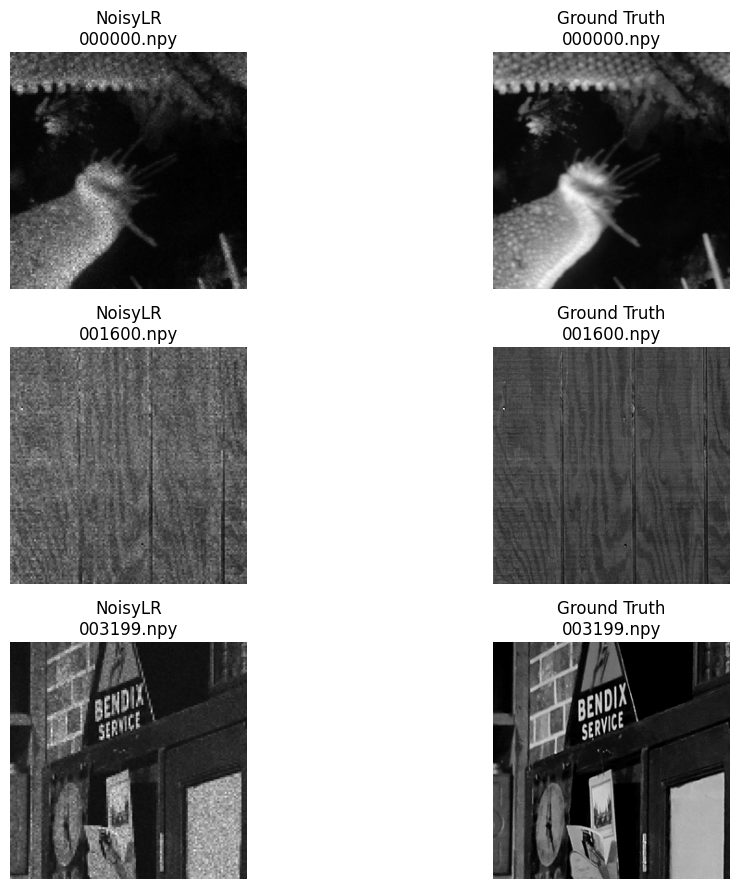

In [9]:
sample_ids = [
    0,
    len(common_files)//2,
    len(common_files)-1
]

plt.figure(
    figsize=(12, 9)
)

for row, idx in enumerate(sample_ids):

    filename = common_files[idx]

    gt = np.load(
        os.path.join(GT_PATH, filename)
    )

    noisy = np.load(
        os.path.join(NOISY_PATH, filename)
    )

    plt.subplot(
        3,
        2,
        row*2 + 1
    )

    plt.imshow(
        noisy,
        cmap="gray"
    )

    plt.title(
        f"NoisyLR\n{filename}"
    )

    plt.axis("off")


    plt.subplot(
        3,
        2,
        row*2 + 2
    )

    plt.imshow(
        gt,
        cmap="gray"
    )

    plt.title(
        f"Ground Truth\n{filename}"
    )

    plt.axis("off")


plt.tight_layout()
plt.show()

In [10]:
sample_file = common_files[0]

gt = np.load(
    os.path.join(
        GT_PATH,
        sample_file
    )
).astype(np.float32)

noisy = np.load(
    os.path.join(
        NOISY_PATH,
        sample_file
    )
).astype(np.float32)

noisy_up = resize(
    noisy,
    gt.shape,
    order=3,
    anti_aliasing=False,
    preserve_range=True
).astype(np.float32)

residual = (
    gt - noisy_up
)

print("Filename:", sample_file)

print("NoisyLR shape:", noisy.shape)
print("Upsampled shape:", noisy_up.shape)
print("GT shape:", gt.shape)

print("\nResidual statistics")

print("Mean:", residual.mean())
print("STD:", residual.std())
print("Variance:", residual.var())
print("Minimum:", residual.min())
print("Maximum:", residual.max())

Filename: 000000.npy
NoisyLR shape: (128, 128)
Upsampled shape: (256, 256)
GT shape: (256, 256)

Residual statistics
Mean: -0.00025243175
STD: 0.044992633
Variance: 0.002024337
Minimum: -0.3562541
Maximum: 0.34291077


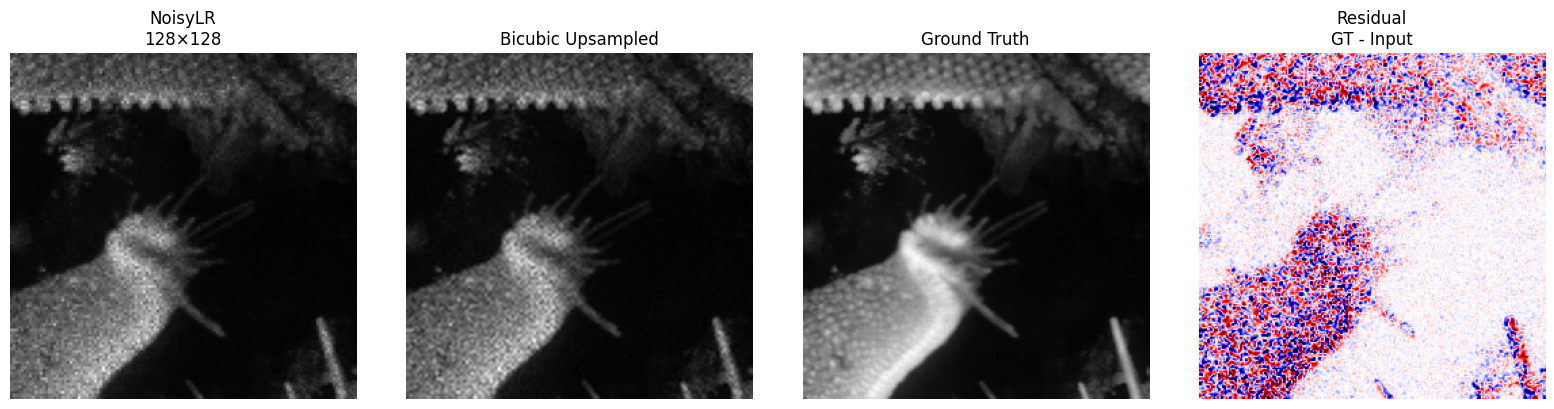

In [11]:
vmax = np.percentile(
    np.abs(residual),
    99
)

plt.figure(
    figsize=(16,4)
)

plt.subplot(1,4,1)

plt.imshow(
    noisy,
    cmap="gray"
)

plt.title(
    "NoisyLR\n128×128"
)

plt.axis("off")


plt.subplot(1,4,2)

plt.imshow(
    noisy_up,
    cmap="gray"
)

plt.title(
    "Bicubic Upsampled"
)

plt.axis("off")


plt.subplot(1,4,3)

plt.imshow(
    gt,
    cmap="gray"
)

plt.title(
    "Ground Truth"
)

plt.axis("off")


plt.subplot(1,4,4)

plt.imshow(
    residual,
    cmap="seismic",
    vmin=-vmax,
    vmax=vmax
)

plt.title(
    "Residual\nGT - Input"
)

plt.axis("off")


plt.tight_layout()
plt.show()

========== RESIDUAL DISTRIBUTION ==========
Mean       : -0.00025243175
STD        : 0.044992633
Skewness   : -0.34075585
Kurtosis   : 7.410036


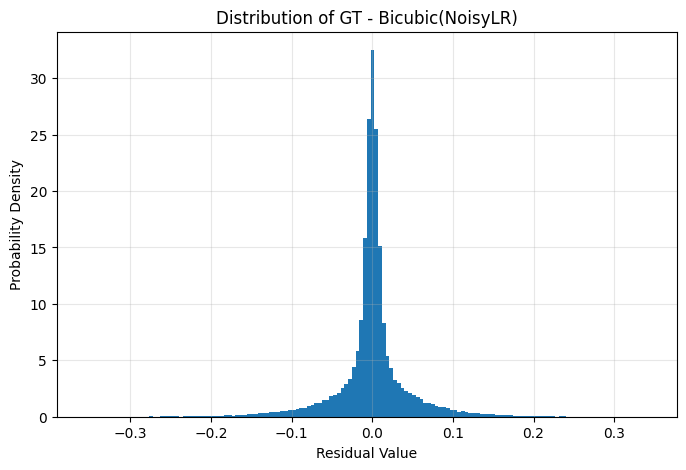

In [12]:
residual_flat = residual.flatten()

print("========== RESIDUAL DISTRIBUTION ==========")

print("Mean       :", np.mean(residual_flat))
print("STD        :", np.std(residual_flat))
print("Skewness   :", skew(residual_flat))
print("Kurtosis   :", kurtosis(residual_flat))

plt.figure(figsize=(8,5))

plt.hist(
    residual_flat,
    bins=150,
    density=True
)

plt.xlabel("Residual Value")
plt.ylabel("Probability Density")
plt.title("Distribution of GT - Bicubic(NoisyLR)")
plt.grid(alpha=0.3)

plt.show()

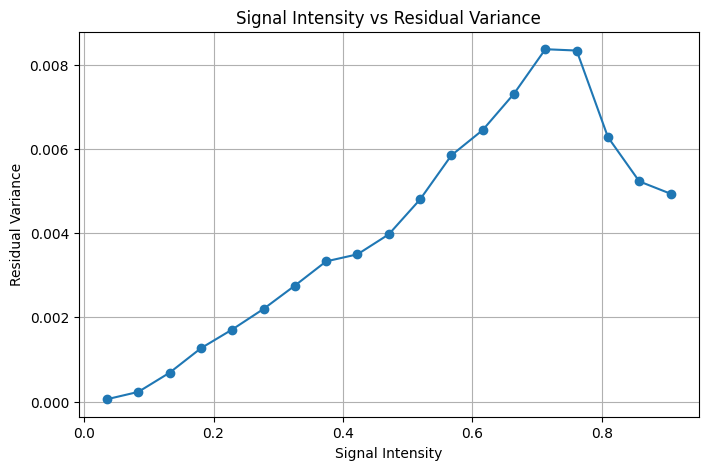

In [13]:
signal = noisy_up.flatten()
error = residual.flatten()

bins = np.linspace(
    np.percentile(signal, 1),
    np.percentile(signal, 99),
    20
)

bin_centers = []
error_variance = []
error_std = []
error_abs_mean = []
counts = []

for i in range(len(bins)-1):

    mask = (
        (signal >= bins[i]) &
        (signal < bins[i+1])
    )

    if np.sum(mask) > 100:

        e = error[mask]

        bin_centers.append(
            (bins[i] + bins[i+1]) / 2
        )

        error_variance.append(
            np.var(e)
        )

        error_std.append(
            np.std(e)
        )

        error_abs_mean.append(
            np.mean(np.abs(e))
        )

        counts.append(
            np.sum(mask)
        )


plt.figure(figsize=(8,5))

plt.plot(
    bin_centers,
    error_variance,
    marker="o"
)

plt.xlabel("Signal Intensity")
plt.ylabel("Residual Variance")
plt.title("Signal Intensity vs Residual Variance")
plt.grid(True)

plt.show()

In [14]:
abs_error = np.abs(error)

correlation = np.corrcoef(
    signal,
    abs_error
)[0,1]

print(
    "Correlation between signal intensity "
    "and absolute restoration error:"
)

print(correlation)

Correlation between signal intensity and absolute restoration error:
0.6610568106995808


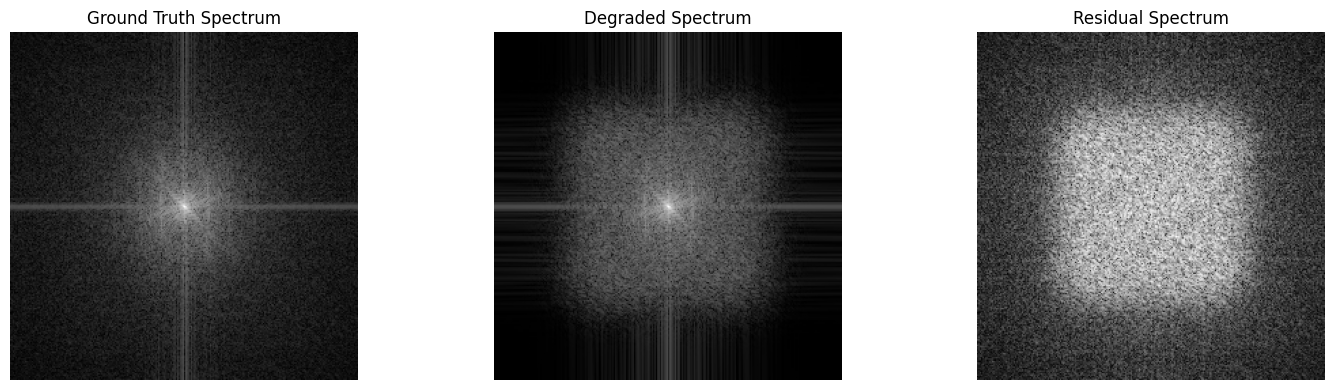

In [15]:
def fft_log_spectrum(image):

    fft = np.fft.fft2(image)

    fft_shift = np.fft.fftshift(
        fft
    )

    spectrum = np.log1p(
        np.abs(fft_shift)
    )

    return spectrum


gt_fft = fft_log_spectrum(
    gt
)

noisy_fft = fft_log_spectrum(
    noisy_up
)

residual_fft = fft_log_spectrum(
    residual
)


plt.figure(figsize=(15,4))

plt.subplot(1,3,1)

plt.imshow(
    gt_fft,
    cmap="gray"
)

plt.title(
    "Ground Truth Spectrum"
)

plt.axis("off")


plt.subplot(1,3,2)

plt.imshow(
    noisy_fft,
    cmap="gray"
)

plt.title(
    "Degraded Spectrum"
)

plt.axis("off")


plt.subplot(1,3,3)

plt.imshow(
    residual_fft,
    cmap="gray"
)

plt.title(
    "Residual Spectrum"
)

plt.axis("off")


plt.tight_layout()
plt.show()

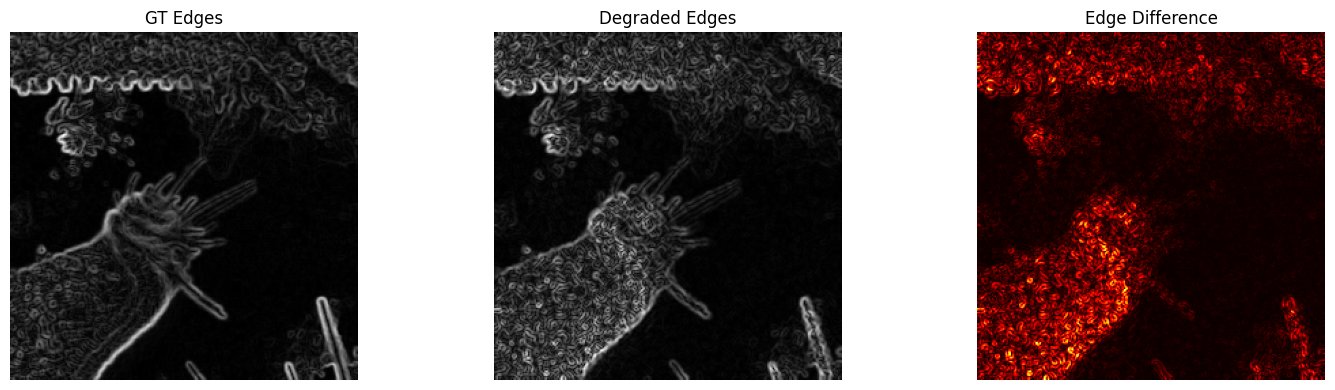

In [16]:
def get_edge_map(image):

    gx = sobel(
        image,
        axis=1
    )

    gy = sobel(
        image,
        axis=0
    )

    return np.sqrt(
        gx**2 + gy**2
    )


gt_edges = get_edge_map(gt)

noisy_edges = get_edge_map(noisy_up)

edge_error = np.abs(
    gt_edges - noisy_edges
)


plt.figure(figsize=(15,4))

plt.subplot(1,3,1)

plt.imshow(
    gt_edges,
    cmap="gray"
)

plt.title("GT Edges")
plt.axis("off")


plt.subplot(1,3,2)

plt.imshow(
    noisy_edges,
    cmap="gray"
)

plt.title("Degraded Edges")
plt.axis("off")


plt.subplot(1,3,3)

plt.imshow(
    edge_error,
    cmap="hot"
)

plt.title("Edge Difference")
plt.axis("off")


plt.tight_layout()
plt.show()

In [17]:
edge_mse = np.mean(
    (gt_edges - noisy_edges)**2
)

edge_mae = np.mean(
    np.abs(gt_edges - noisy_edges)
)

edge_corr = np.corrcoef(
    gt_edges.flatten(),
    noisy_edges.flatten()
)[0,1]

print(
    "========== EDGE DEGRADATION =========="
)

print(
    "Edge MSE:",
    edge_mse
)

print(
    "Edge MAE:",
    edge_mae
)

print(
    "Edge correlation:",
    edge_corr
)

print(
    "GT mean edge strength:",
    np.mean(gt_edges)
)

print(
    "Degraded mean edge strength:",
    np.mean(noisy_edges)
)

========== EDGE DEGRADATION ==========
Edge MSE: 0.04606176
Edge MAE: 0.118895695
Edge correlation: 0.7442856633820728
GT mean edge strength: 0.17571306
Degraded mean edge strength: 0.25402293


In [18]:
dataset_stats = []

for k, filename in enumerate(common_files):

    gt_i = np.load(
        os.path.join(GT_PATH, filename)
    ).astype(np.float32)

    lr_i = np.load(
        os.path.join(NOISY_PATH, filename)
    ).astype(np.float32)

    # Upsample LR to GT resolution
    lr_up = resize(
        lr_i,
        gt_i.shape,
        order=3,
        anti_aliasing=False,
        preserve_range=True
    ).astype(np.float32)

    residual_i = gt_i - lr_up

    signal_i = lr_up.flatten()
    error_i = residual_i.flatten()

    # Residual statistics
    res_std = np.std(error_i)
    res_skew = skew(error_i)
    res_kurt = kurtosis(error_i)

    # Signal-dependent error
    corr_intensity_error = np.corrcoef(
        signal_i,
        np.abs(error_i)
    )[0, 1]

    # Edge statistics
    gt_edge = get_edge_map(gt_i)
    lr_edge = get_edge_map(lr_up)

    edge_mae_i = np.mean(
        np.abs(gt_edge - lr_edge)
    )

    edge_corr_i = np.corrcoef(
        gt_edge.flatten(),
        lr_edge.flatten()
    )[0, 1]

    dataset_stats.append({
        "file": filename,
        "residual_std": res_std,
        "skewness": res_skew,
        "kurtosis": res_kurt,
        "intensity_error_corr": corr_intensity_error,
        "edge_mae": edge_mae_i,
        "edge_corr": edge_corr_i,
        "gt_edge_strength": np.mean(gt_edge),
        "lr_edge_strength": np.mean(lr_edge)
    })

    if (k + 1) % 500 == 0:
        print(
            f"Processed {k+1}/{len(common_files)}"
        )

stats_df = pd.DataFrame(dataset_stats)

print("\nAnalysis complete.")
print(stats_df.head())

Processed 500/3200
Processed 1000/3200
Processed 1500/3200
Processed 2000/3200
Processed 2500/3200
Processed 3000/3200

Analysis complete.
         file  residual_std  skewness  kurtosis  intensity_error_corr  \
0  000000.npy      0.044993 -0.340756  7.410036              0.661057   
1  000001.npy      0.055146 -0.380862  2.755002              0.459058   
2  000002.npy      0.048768 -0.238515  2.892498              0.459040   
3  000003.npy      0.042506 -0.214382  2.793981              0.454977   
4  000004.npy      0.106098 -0.111051  2.074739              0.321423   

   edge_mae  edge_corr  gt_edge_strength  lr_edge_strength  
0  0.118896   0.744286          0.175713          0.254023  
1  0.202745   0.453499          0.162732          0.335994  
2  0.173006   0.481638          0.162622          0.302881  
3  0.147671   0.528689          0.157527          0.272060  
4  0.316579   0.539761          0.504526          0.595915  


In [19]:
summary = stats_df.describe().T

print(
    "========== DATASET-WIDE DEGRADATION SUMMARY =========="
)

display(summary)

========== DATASET-WIDE DEGRADATION SUMMARY ==========


,count,mean,std,min,25%,50%,75%,max
residual_std,3200.0,0.081927,0.032664,0.009330,0.061818,0.079670,0.098337,0.320994
skewness,3200.0,-0.243265,0.269245,-5.173837,-0.280235,-0.219025,-0.166392,4.026542
kurtosis,3200.0,4.504732,16.776054,-0.114157,0.967992,1.949362,4.232753,525.084778
intensity_error_corr,3200.0,0.378595,0.159462,-0.231429,0.263495,0.384781,0.500039,0.751036
edge_mae,3200.0,0.301543,0.140725,0.022227,0.201129,0.284787,0.378469,0.881924
edge_corr,3200.0,0.445705,0.258107,-0.304884,0.228539,0.493362,0.662541,0.912550
gt_edge_strength,3200.0,0.277924,0.188108,0.018219,0.142351,0.239470,0.364138,1.309665
lr_edge_strength,3200.0,0.488195,0.188894,0.042222,0.366965,0.476636,0.595953,1.405337


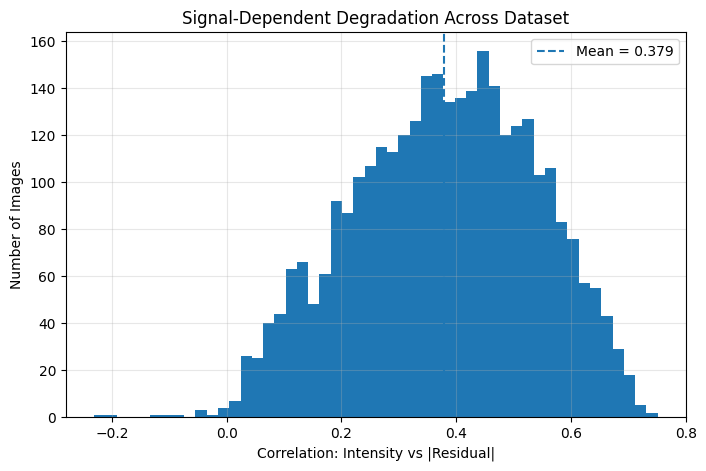

Mean correlation: 0.37859486194947406
Median correlation: 0.3847808172474807
Images with correlation > 0.3: 68.1875 %
Images with correlation > 0.5: 25.0 %


In [20]:
plt.figure(figsize=(8,5))

plt.hist(
    stats_df["intensity_error_corr"],
    bins=50
)

plt.axvline(
    stats_df["intensity_error_corr"].mean(),
    linestyle="--",
    label=f'Mean = {stats_df["intensity_error_corr"].mean():.3f}'
)

plt.xlabel(
    "Correlation: Intensity vs |Residual|"
)

plt.ylabel("Number of Images")

plt.title(
    "Signal-Dependent Degradation Across Dataset"
)

plt.legend()
plt.grid(alpha=0.3)

plt.show()


print(
    "Mean correlation:",
    stats_df["intensity_error_corr"].mean()
)

print(
    "Median correlation:",
    stats_df["intensity_error_corr"].median()
)

print(
    "Images with correlation > 0.3:",
    np.mean(
        stats_df["intensity_error_corr"] > 0.3
    ) * 100,
    "%"
)

print(
    "Images with correlation > 0.5:",
    np.mean(
        stats_df["intensity_error_corr"] > 0.5
    ) * 100,
    "%"
)

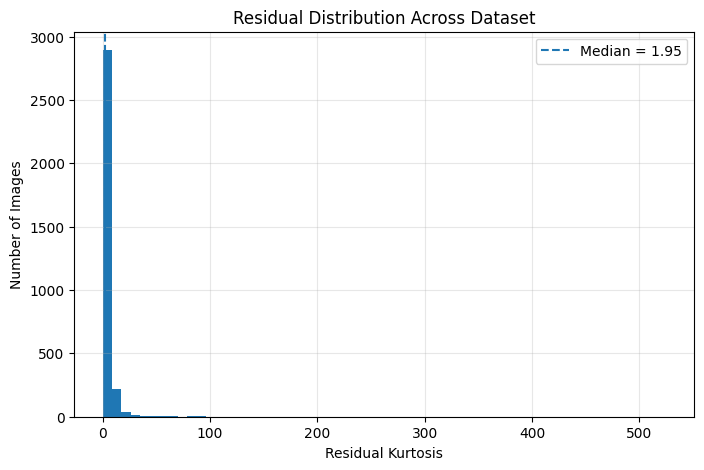

Mean kurtosis: 4.5047317
Median kurtosis: 1.9493618
Images with kurtosis > 3: 34.3125 %


In [21]:
plt.figure(figsize=(8,5))

plt.hist(
    stats_df["kurtosis"],
    bins=60
)

plt.axvline(
    stats_df["kurtosis"].median(),
    linestyle="--",
    label=f'Median = {stats_df["kurtosis"].median():.2f}'
)

plt.xlabel("Residual Kurtosis")
plt.ylabel("Number of Images")

plt.title(
    "Residual Distribution Across Dataset"
)

plt.legend()
plt.grid(alpha=0.3)

plt.show()


print(
    "Mean kurtosis:",
    stats_df["kurtosis"].mean()
)

print(
    "Median kurtosis:",
    stats_df["kurtosis"].median()
)

print(
    "Images with kurtosis > 3:",
    np.mean(
        stats_df["kurtosis"] > 3
    ) * 100,
    "%"
)

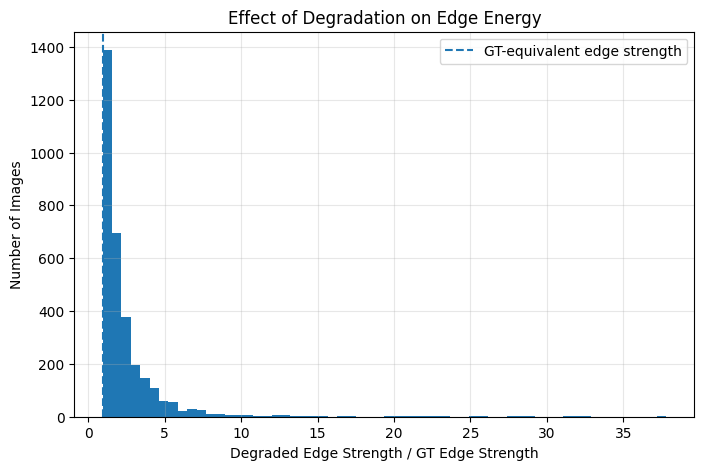

Mean edge ratio: 2.5403588
Median edge ratio: 1.6989877
Images with stronger degraded edges: 98.5 %


In [22]:
edge_ratio = (
    stats_df["lr_edge_strength"] /
    (stats_df["gt_edge_strength"] + 1e-8)
)

stats_df["edge_strength_ratio"] = edge_ratio


plt.figure(figsize=(8,5))

plt.hist(
    edge_ratio,
    bins=60
)

plt.axvline(
    1.0,
    linestyle="--",
    label="GT-equivalent edge strength"
)

plt.xlabel(
    "Degraded Edge Strength / GT Edge Strength"
)

plt.ylabel(
    "Number of Images"
)

plt.title(
    "Effect of Degradation on Edge Energy"
)

plt.legend()
plt.grid(alpha=0.3)

plt.show()


print(
    "Mean edge ratio:",
    edge_ratio.mean()
)

print(
    "Median edge ratio:",
    edge_ratio.median()
)

print(
    "Images with stronger degraded edges:",
    np.mean(edge_ratio > 1) * 100,
    "%"
)

In [23]:
RESULT_DIR = "../results/degradation_analysis"

os.makedirs(
    RESULT_DIR,
    exist_ok=True
)

stats_df.to_csv(
    os.path.join(
        RESULT_DIR,
        "dataset_degradation_statistics.csv"
    ),
    index=False
)

summary.to_csv(
    os.path.join(
        RESULT_DIR,
        "dataset_degradation_summary.csv"
    )
)

print(
    "Results saved to:",
    RESULT_DIR
)

Results saved to: ../results/degradation_analysis


In [24]:
q1 = stats_df["residual_std"].quantile(0.33)
q2 = stats_df["residual_std"].quantile(0.66)

def severity(x):

    if x <= q1:
        return "Low"

    elif x <= q2:
        return "Medium"

    else:
        return "High"


stats_df["severity"] = (
    stats_df["residual_std"]
    .apply(severity)
)

print("Thresholds")
print("Low/Medium :", q1)
print("Medium/High:", q2)

print("\nDistribution")
print(
    stats_df["severity"].value_counts()
)

Thresholds
Low/Medium : 0.06774894379079342
Medium/High: 0.09118832513689996

Distribution
severity
High      1088
Low       1056
Medium    1056
Name: count, dtype: int64


In [25]:
severity_summary = (
    stats_df
    .groupby("severity")
    [
        [
            "residual_std",
            "kurtosis",
            "intensity_error_corr",
            "edge_mae",
            "edge_corr",
            "edge_strength_ratio"
        ]
    ]
    .mean()
)

display(severity_summary)

,residual_std,kurtosis,intensity_error_corr,edge_mae,edge_corr,edge_strength_ratio
severity,,,,,,
High,0.113993,1.147687,0.252511,0.443803,0.320182,3.491031
Low,0.051226,9.978244,0.497808,0.165342,0.607692,1.758749
Medium,0.079592,2.489992,0.389286,0.291173,0.413046,2.342488


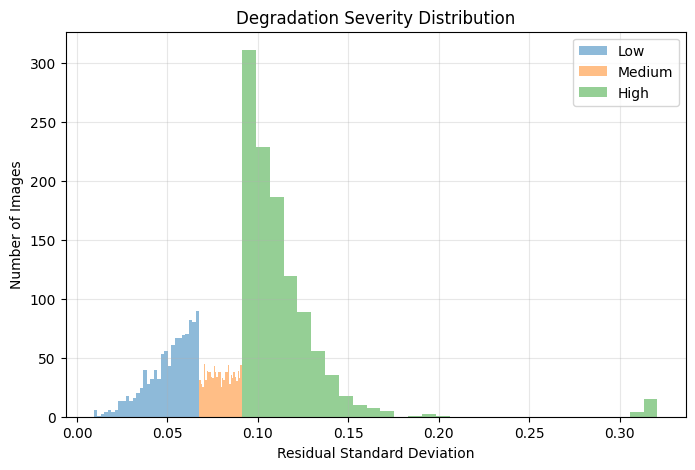

In [26]:
plt.figure(figsize=(8,5))

for group in ["Low", "Medium", "High"]:

    values = stats_df[
        stats_df["severity"] == group
    ]["residual_std"]

    plt.hist(
        values,
        bins=30,
        alpha=0.5,
        label=group
    )

plt.xlabel("Residual Standard Deviation")
plt.ylabel("Number of Images")

plt.title(
    "Degradation Severity Distribution"
)

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [27]:
representatives = {}

for group in ["Low", "Medium", "High"]:

    subset = stats_df[
        stats_df["severity"] == group
    ]

    target = subset[
        "residual_std"
    ].median()

    idx = (
        subset["residual_std"]
        - target
    ).abs().idxmin()

    representatives[group] = (
        stats_df.loc[idx, "file"]
    )


print(
    "Representative samples:"
)

for group, file in representatives.items():

    print(
        group,
        "->",
        file
    )

Representative samples:
Low -> 001514.npy
Medium -> 002499.npy
High -> 000577.npy


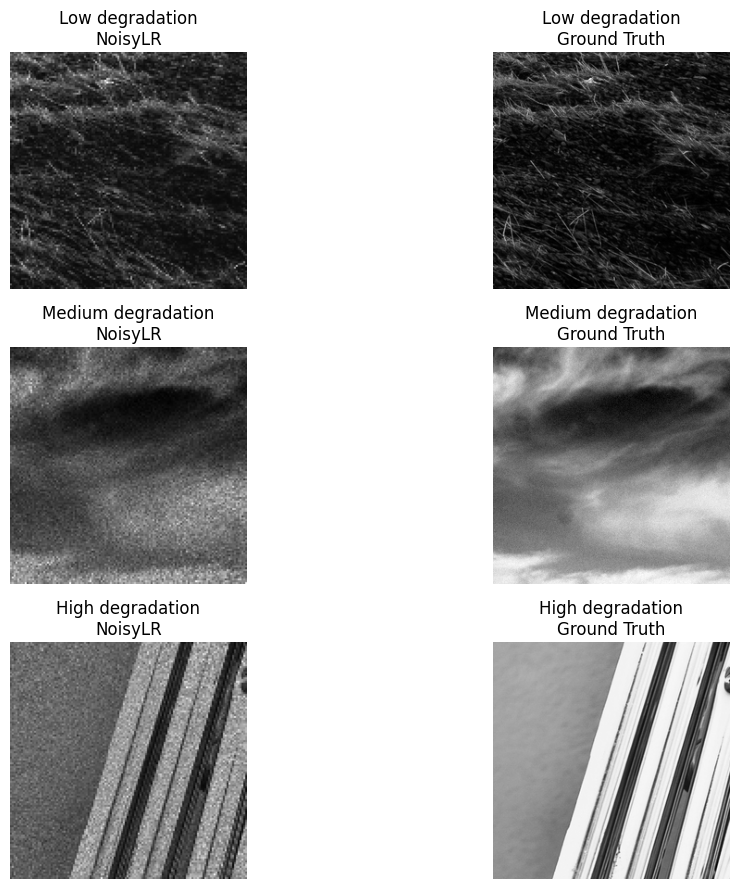

In [28]:
plt.figure(figsize=(12,9))

for row, group in enumerate(
    ["Low", "Medium", "High"]
):

    filename = representatives[group]

    gt_i = np.load(
        os.path.join(
            GT_PATH,
            filename
        )
    )

    lr_i = np.load(
        os.path.join(
            NOISY_PATH,
            filename
        )
    )

    plt.subplot(
        3, 2,
        row*2 + 1
    )

    plt.imshow(
        lr_i,
        cmap="gray"
    )

    plt.title(
        f"{group} degradation\nNoisyLR"
    )

    plt.axis("off")


    plt.subplot(
        3, 2,
        row*2 + 2
    )

    plt.imshow(
        gt_i,
        cmap="gray"
    )

    plt.title(
        f"{group} degradation\nGround Truth"
    )

    plt.axis("off")


plt.tight_layout()
plt.show()

In [29]:
stats_df.to_csv(
    "../results/degradation_analysis/"
    "dataset_degradation_statistics.csv",
    index=False
)

severity_summary.to_csv(
    "../results/degradation_analysis/"
    "severity_summary.csv"
)

print(
    "Updated degradation analysis saved."
)

Updated degradation analysis saved.
